In [1]:
import gymnasium as gym # https://gymnasium.farama.org/
import time
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import Sequential, layers, optimizers, losses, activations
from tensorflow import GradientTape
import tensorflow as tf
import seaborn as sns
import matplotlib as mpl

# To get smooth animations
import matplotlib.animation as animation

In [2]:
mpl.rc('animation', html='jshtml')
sns.set_style('whitegrid')

In [3]:
gym.envs.registry.items()

dict_items([('CartPole-v0', EnvSpec(id='CartPole-v0', entry_point='gymnasium.envs.classic_control.cartpole:CartPoleEnv', reward_threshold=195.0, nondeterministic=False, max_episode_steps=200, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='CartPole', version=0, additional_wrappers=(), vector_entry_point='gymnasium.envs.classic_control.cartpole:CartPoleVectorEnv')), ('CartPole-v1', EnvSpec(id='CartPole-v1', entry_point='gymnasium.envs.classic_control.cartpole:CartPoleEnv', reward_threshold=475.0, nondeterministic=False, max_episode_steps=500, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='CartPole', version=1, additional_wrappers=(), vector_entry_point='gymnasium.envs.classic_control.cartpole:CartPoleVectorEnv')), ('MountainCar-v0', EnvSpec(id='MountainCar-v0', entry_point='gymnasium.envs.classic_control.mountain_car:MountainCarEnv', reward_threshold=-110.0, nondeterministic=False, max_episode_steps=200, order_enforce=True

In [4]:
env = gym.make("LunarLander-v3", render_mode="human")
obs, info = env.reset(seed=42)

for _ in range(1000):

    # this is where you would insert your policy
    action = env.action_space.sample()

    # step (transition) through the environment with the action
    # receiving the next observation, reward and if the episode has terminated or truncated
    obs, reward, terminated, truncated, info = env.step(action)

    # optional: slow it a bit so you can see what's happening
    time.sleep(1/60)

    # If the episode has ended then we can reset to start a new episode
    if terminated or truncated:
        obs, info = env.reset()

env.close()

C:\Users\username\Projects\MachineLearning\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [5]:
env = gym.make('CartPole-v1') # create the environment
obs = env.reset(seed=42) # reset the environment to get the initial
obs # the observation is a 1D array of 4 numbers: [cart position, cart velocity, pole angle, pole angular velocity]

(array([ 0.0273956 , -0.00611216,  0.03585979,  0.0197368 ], dtype=float32),
 {})

In [6]:
env = gym.make('CartPole-v1', render_mode='rgb_array') # create the environment
obs, info = env.reset(seed=42) # reset the environment to get the initial observation and info

img = env.render() # render the environment and get the image as a numpy array
img.shape # the image is 400 pixels wide, 600 pixels high and has 3

(400, 600, 3)

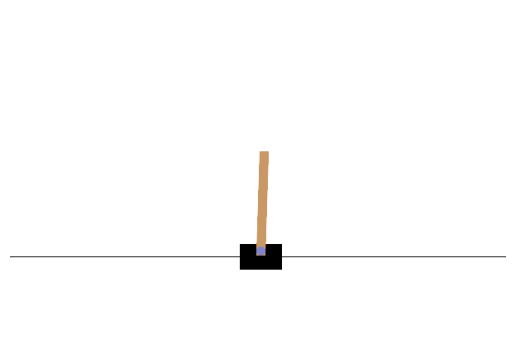

In [7]:
plt.imshow(img) # display the image
plt.axis('off') # hide the axes
plt.show() # show the plot

In [8]:
env.action_space # the action space is discrete with 2 possible actions: 0 (push cart to the left) and 1 (push cart to the right)

Discrete(2)

In [9]:
action = 1 # choose an action (in this case, we choose to push the cart to the right)
obs, reward, terminated, truncated, info = env.step(action) # take the action and observe the result
print(f'Obesrvation: {obs}, Reward: {reward}, Terminated: {terminated}, Truncated: {truncated}')

Obesrvation: [ 0.02727336  0.18847767  0.03625453 -0.26141977], Reward: 1.0, Terminated: False, Truncated: False


In [10]:
caty_position, cart_velocity, pole_angle, pole_angular_velocity = obs
print(f'Cart Position: {caty_position}, Cart Velocity: {cart_velocity}, Pole Angle: {pole_angle}, Pole Angular Velocity: {pole_angular_velocity}')

Cart Position: 0.02727336250245571, Cart Velocity: 0.18847766518592834, Pole Angle: 0.036254528909921646, Pole Angular Velocity: -0.26141977310180664


In [11]:
obs # obs[0] is the cart position, obs[1] is the cart velocity, obs[2] is the pole angle and obs[3] is the pole angular velocity
reward # the reward is 1 for every step taken, including the termination step, where the pole is more than 15 degrees from vertical, or the cart moves more than 2.4 units from the center
terminated # the episode is terminated if the pole is more than 15 degrees from vertical, or the cart moves more than 2.4 units from the center, or if the episode length is greater than 500 steps
info # specific info ( lives left for example )
truncated # the episode is truncated if the episode length is greater than 500 steps

False

# Manual Politics

In [12]:
def basic_policy(obs):
    """ Simple manual politic """
    _, _, pole_angle, _ = obs
    return 0 if pole_angle < 0 else 1

In [13]:
env = gym.make("CartPole-v1", render_mode="rgb_array")

In [14]:
totals = []
for episode in range(200):
    obs, info = env.reset()  # don't reseed every episode
    terminated = truncated = False
    episode_rewards = 0
    step = 0

    while not (terminated or truncated):
        action = basic_policy(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        episode_rewards += reward
        step += 1

    totals.append(episode_rewards)

env.close()

print("mean/std/min/max:", np.mean(totals), np.std(totals), np.min(totals), np.max(totals))

mean/std/min/max: 41.81 8.292400135063431 25.0 71.0


## Using DNN for Politics

- Model need to decide where need to move: left or right
- There are 1 output neuron (0 for left, 1 for right ) probability expected
- CartPole is simple env - no noise, clear state included, simple to catch.

In [27]:
def render_policy_net(model, n_max_steps=200, seed=42):
    frames = []
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    np.random.seed(seed)
    obs, info = env.reset(seed=seed)
    for step in range(n_max_steps):
        frames.append(env.render())

        left_proba = model.predict(obs.reshape(1, -1), verbose=0)[0, 0]
        action = 0 if np.random.rand() < left_proba else 1

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        if done:
            break
    env.close()
    return frames

In [16]:
def update_scene(num, frames, patch):
    patch.set_data(frames[num])
    return patch,

def plot_animation(frames, repeat=False, interval=40):
    fig = plt.figure()
    patch = plt.imshow(frames[0])
    plt.axis('off')
    anim = animation.FuncAnimation(
        fig, update_scene, fargs=(frames, patch),
        frames=len(frames), repeat=repeat, interval=interval)
    plt.close()
    return anim

## Action Training

- credit assignment problems ( we don't know what good\bad result of our actions )
- reward delayed
- discount factor ( action scoring all rewards )
- return factor ( sum of all discount factor )
- action advantage ( comparing results of previous actions )

## Politics gradient

>  REINFORCE ( REward Increment = non-negative Factor x Offset Reinforcement )

1. Play Env with model and calculate gradient ( but do not apply gradients )
2. After few runs calculate importance for each a actions
3. Increase or decrease probability of next action by good \ bad results
4. You can use calculated gradients

# One Step Function for Training model

In [17]:
def play_one_step(env, obs, model: Sequential, loss_fn: callable):
    with GradientTape() as tape:
        left_proba = model(obs[np.newaxis])
        action = (tf.random.uniform([1,1]) > left_proba)
        y_target = tf.constant([[1.]]) - tf.cast(action, tf.float32)
        loss = tf.reduce_mean(loss_fn(y_target, left_proba))
    grads = tape.gradient(loss, model.trainable_variables)
    # obs, reward, terminated, truncated, info
    obs, reward, done, truncated, info = env.step(int(action[0, 0].numpy()))
    return obs, reward, done, grads

# Multiple Episodes Function which depends on OneStepFunction

In [18]:
def play_multiple_episodes(env, n_episodes: int, n_max_steps: int, model: Sequential, loss_fn: callable):
    all_rewards = []
    all_grads = []
    for episode in range(n_episodes):
        current_rewards = []
        current_grads = []
        obs, info = env.reset()
        for step in range(n_max_steps):
            obs, reward, done, grads = play_one_step(env, obs, model, loss_fn)
            current_rewards.append(reward)
            current_grads.append(grads)
            if done:
                break
        all_rewards.append(current_rewards)
        all_grads.append(current_grads)
    return all_rewards, all_grads

In [19]:
def discount_rewards(rewards, discount_rate):
    """ calculate sum of discounted future rewards """
    discounted = np.array(rewards)
    for step in range(len(rewards) - 2, -1, -1):
        discounted[step] += discounted[step + 1] * discount_rate
    return discounted

def discount_and_normalize_rewards(all_rewards, discount_rate):
    """ Normalization of all discounted rewards x = x - x.mean() / x.std() """
    all_discounted_rewards = [discount_rewards(rewards, discount_rate)
                              for rewards in all_rewards]
    flat_rewards = np.concatenate(all_discounted_rewards)
    reward_mean = flat_rewards.mean()
    reward_std = flat_rewards.std()
    return [(discounted_rewards - reward_mean) / reward_std
            for discounted_rewards in all_discounted_rewards]

In [20]:
result = discount_rewards([10, 0, -50], 0.8)
print(result)

normalized_results = discount_and_normalize_rewards([[10, 0, -50], [10,20]], 0.8)
print(normalized_results) # First episode was bad (all values are negative) Second is good ( positive values )

[-22 -40 -50]
[array([-0.28435071, -0.86597718, -1.18910299]), array([1.26665318, 1.0727777 ])]


# Hyperparams initialization

In [21]:
n_iterations = 150
n_episodes_per_update = 10
n_max_steps = 200
discount_factor = 0.95

optimizer = optimizers.Adam(learning_rate=0.01)
loss_fn = losses.binary_crossentropy

In [22]:
env = gym.make("CartPole-v1", render_mode="rgb_array")

In [23]:
shape = env.observation_space.shape[0]

model = Sequential([
    layers.Input(shape=[shape]),
    layers.Dense(5, activation=activations.relu),
    layers.Dense(1, activation='sigmoid')
])

## Training

In [24]:
for iteration in range(n_iterations):
    all_rewards, all_grads = play_multiple_episodes(
        env, n_episodes_per_update, n_max_steps, model, loss_fn)
    total_rewards = sum(map(sum, all_rewards))                     # Not shown in the book
    print("\rIteration: {}, mean rewards: {:.1f}".format(          # Not shown
        iteration, total_rewards / n_episodes_per_update), end="") # Not shown
    all_final_rewards = discount_and_normalize_rewards(all_rewards,
                                                       discount_factor)
    all_mean_grads = []
    for var_index in range(len(model.trainable_variables)):
        mean_grads = tf.reduce_mean(
            [final_reward * all_grads[episode_index][step][var_index]
             for episode_index, final_rewards in enumerate(all_final_rewards)
                 for step, final_reward in enumerate(final_rewards)], axis=0)
        all_mean_grads.append(mean_grads)
    optimizer.apply_gradients(zip(all_mean_grads, model.trainable_variables))

env.close()

Iteration: 149, mean rewards: 168.3

In [28]:
frames = render_policy_net(model)
plot_animation(frames)

## Markov Chain Decision Training

In [29]:
np.random.seed(42)

transition_probabilities = [ # shape=[s, s']
        [0.7, 0.2, 0.0, 0.1],  # from s0 to s0, s1, s2, s3
        [0.0, 0.0, 0.9, 0.1],  # from s1 to ...
        [0.0, 1.0, 0.0, 0.0],  # from s2 to ...
        [0.0, 0.0, 0.0, 1.0]]  # from s3 to ...

n_max_steps = 50

def print_sequence():
    current_state = 0
    print("States:", end=" ")
    for step in range(n_max_steps):
        print(current_state, end=" ")
        if current_state == 3:
            break
        current_state = np.random.choice(range(4), p=transition_probabilities[current_state])
    else:
        print("...", end="")
    print()

for _ in range(10):
    print_sequence()

States: 0 0 3 
States: 0 1 2 1 2 1 2 1 2 1 3 
States: 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 3 
States: 0 3 
States: 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 3 
States: 0 1 3 
States: 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 ...
States: 0 0 3 
States: 0 0 0 1 2 1 2 1 3 
States: 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 3 


## Markov Decision Process

In [30]:
# Let's define some transition probabilities, rewards and possible actions.
# For example, in state s0, if action a0 is chosen then with proba 0.7 we will go to state s0 with reward +10, with probability 0.3 we will go to state s1 with no reward,
# and with never go to state s2 (so the transition probabilities are [0.7, 0.3, 0.0], and the rewards are [+10, 0, 0]):

transition_probabilities = [ # shape=[s, a, s']
        [[0.7, 0.3, 0.0], [1.0, 0.0, 0.0], [0.8, 0.2, 0.0]],
        [[0.0, 1.0, 0.0], None, [0.0, 0.0, 1.0]],
        [None, [0.8, 0.1, 0.1], None]]
rewards = [ # shape=[s, a, s']
        [[+10, 0, 0], [0, 0, 0], [0, 0, 0]],
        [[0, 0, 0], [0, 0, 0], [0, 0, -50]],
        [[0, 0, 0], [+40, 0, 0], [0, 0, 0]]]
possible_actions = [[0, 1, 2], [0, 2], [1]]

# Q-Value Iteration

In [31]:
Q_values = np.full((3, 3), -np.inf) # -np.inf for impossible actions
for state, actions in enumerate(possible_actions):
    Q_values[state, actions] = 0.0  # for all possible actions

In [32]:
gamma = 0.90  # the discount factor

history1 = [] # Not shown in the book (for the figure below)
for iteration in range(50):
    Q_prev = Q_values.copy()
    history1.append(Q_prev) # Not shown
    for s in range(3):
        for a in possible_actions[s]:
            Q_values[s, a] = np.sum([
                    transition_probabilities[s][a][sp]
                    * (rewards[s][a][sp] + gamma * np.max(Q_prev[sp]))
                for sp in range(3)])

history1 = np.array(history1) # Not shown

In [33]:
Q_values

array([[18.91891892, 17.02702702, 13.62162162],
       [ 0.        ,        -inf, -4.87971488],
       [       -inf, 50.13365013,        -inf]])

In [34]:
# The optimal policy for this MDP, when using a discount factor of 0.90, is to choose action a0 when in state s0, and choose action a0 when in state s1,
# and finally choose action a1 (the only possible action) when in state s2.
np.argmax(Q_values, axis=1)

array([0, 0, 1])

In [35]:
# Let's try again with a discount factor of 0.95:
Q_values = np.full((3, 3), -np.inf) # -np.inf for impossible actions
for state, actions in enumerate(possible_actions):
    Q_values[state, actions] = 0.0  # for all possible actions

In [36]:
gamma = 0.95  # the discount factor

for iteration in range(50):
    Q_prev = Q_values.copy()
    for s in range(3):
        for a in possible_actions[s]:
            Q_values[s, a] = np.sum([
                    transition_probabilities[s][a][sp]
                    * (rewards[s][a][sp] + gamma * np.max(Q_prev[sp]))
                for sp in range(3)])

In [37]:
Q_values

array([[21.73304188, 20.63807938, 16.70138772],
       [ 0.95462106,        -inf,  1.01361207],
       [       -inf, 53.70728682,        -inf]])

In [38]:
np.argmax(Q_values, axis=1)
# Now the policy has changed! In state s1, we now prefer to go through the fire (choose action a2).
# This is because the discount factor is larger so the agent values the future more, and it is therefore ready to pay an immediate penalty in order to get more future rewards.

array([0, 2, 1])

# Q-Learning

> Q-Learning works by watching an agent play (e.g., randomly) and gradually improving its estimates of the Q-Values. Once it has accurate Q-Value estimates (or close enough), then the optimal policy consists in choosing the action that has the highest Q-Value (i.e., the greedy policy).

We will need to simulate an agent moving around in the environment, so let's define a function to perform some action and get the new state and a reward:

In [39]:
def step(state, action):
    probas = transition_probabilities[state][action]
    next_state = np.random.choice([0, 1, 2], p=probas)
    reward = rewards[state][action][next_state]
    return next_state, reward

# We also need an exploration policy, which can be any policy, as long as it visits every possible state many times. We will just use a random policy, since the state space is very small:
def exploration_policy(state):
    return np.random.choice(possible_actions[state])

# Now let's initialize the Q-Values like earlier, and run the Q-Learning algorithm:
np.random.seed(42)

Q_values = np.full((3, 3), -np.inf)
for state, actions in enumerate(possible_actions):
    Q_values[state][actions] = 0

alpha0 = 0.05 # initial learning rate
decay = 0.005 # learning rate decay
gamma = 0.90 # discount factor
state = 0 # initial state
history2 = [] # Not shown in the book

for iteration in range(10000):
    history2.append(Q_values.copy()) # Not shown
    action = exploration_policy(state)
    next_state, reward = step(state, action)
    next_value = np.max(Q_values[next_state]) # greedy policy at the next step
    alpha = alpha0 / (1 + iteration * decay)
    Q_values[state, action] *= 1 - alpha
    Q_values[state, action] += alpha * (reward + gamma * next_value)
    state = next_state

history2 = np.array(history2) # Not shown

In [40]:
Q_values

array([[18.77621289, 17.2238872 , 13.74543343],
       [ 0.        ,        -inf, -8.00485647],
       [       -inf, 49.40208921,        -inf]])

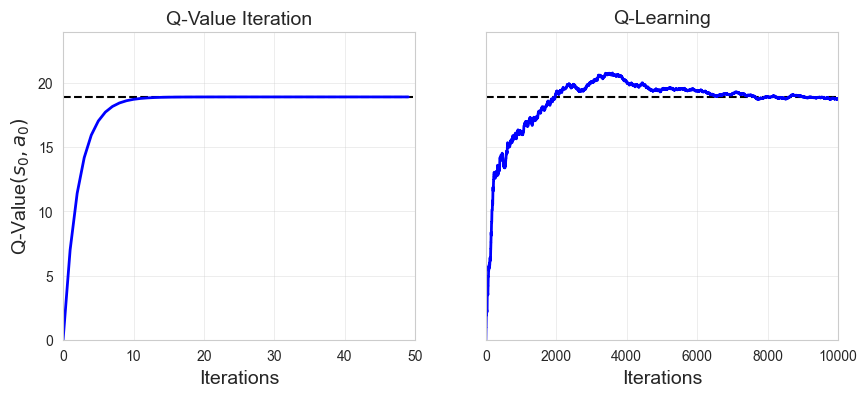

In [41]:
true_Q_value = history1[-1, 0, 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].set_ylabel("Q-Value$(s_0, a_0)$", fontsize=14)
axes[0].set_title("Q-Value Iteration", fontsize=14)
axes[1].set_title("Q-Learning", fontsize=14)
for ax, width, history in zip(axes, (50, 10000), (history1, history2)):
    ax.plot([0, width], [true_Q_value, true_Q_value], "k--")
    ax.plot(np.arange(width), history[:, 0, 0], "b-", linewidth=2)
    ax.set_xlabel("Iterations", fontsize=14)
    ax.axis([0, width, 0, 24])

# Deep Q-Network

Let's build the DQN. Given a state, it will estimate, for each possible action, the sum of discounted future rewards it can expect after it plays that action (but before it sees its outcome):

In [45]:
from collections import deque

seed = 42

tf.keras.backend.clear_session()
tf.random.set_seed(seed=seed)
np.random.seed(seed=seed)

env = gym.make("CartPole-v1", render_mode='rgb_array')
obs, info = env.reset(seed=seed)
input_shape = [4] # == env.observation_space.shape
n_outputs = 2 # == env.action_space.n

model = Sequential([
    layers.Input(shape=input_shape),
    layers.Dense(32, activation="elu"),
    layers.Dense(32, activation="elu"),
    layers.Dense(n_outputs)
])

# To select an action using this DQN, we just pick the action with the largest predicted Q-value.
# However, to ensure that the agent explores the environment, we choose a random action with probability epsilon.

def epsilon_greedy_policy(state, epsilon=0):
    state = np.asarray(state, dtype=np.float32)

    if np.random.rand() < epsilon:
        return np.random.randint(n_outputs)

    q_values = model.predict(state[np.newaxis], verbose=0)
    return int(np.argmax(q_values[0]))


# We will also need a replay memory. It will contain the agent's experiences, in the form of tuples: (obs, action, reward, next_obs, done).
# We can use the deque class for that (but make sure to check out DeepMind's excellent Reverb library for a much more robust implementation of experience replay):
replay_memory = deque(maxlen=2000)

# And let's create a function to sample experiences from the replay memory. It will return 5 NumPy arrays: [obs, actions, rewards, next_obs, dones].
def sample_experiences(batch_size):
    indices = np.random.randint(len(replay_memory), size=batch_size)
    batch = [replay_memory[index] for index in indices]

    states = np.stack([experience[0] for experience in batch]).astype(np.float32)
    actions = np.array([experience[1] for experience in batch], dtype=np.int32)
    rewards = np.array([experience[2] for experience in batch], dtype=np.float32)
    next_states = np.stack([experience[3] for experience in batch]).astype(np.float32)
    dones = np.array([experience[4] for experience in batch], dtype=np.float32)

    return states, actions, rewards, next_states, dones

# Now we can create a function that will use the DQN to play one step, and record its experience in the replay memory:
def play_one_step(env, state, epsilon):
    state = np.asarray(state, dtype=np.float32)

    action = epsilon_greedy_policy(state, epsilon)
    next_state, reward, terminated, truncated, info = env.step(action)
    next_state = np.asarray(next_state, dtype=np.float32)

    done = terminated or truncated
    replay_memory.append((state, action, reward, next_state, done))
    return next_state, reward, done, info

# Lastly, let's create a function that will sample some experiences from the replay memory and perform a training step:

# Notes:
# The first 3 releases of the 2nd edition were missing the reshape() operation which converts target_Q_values to a column vector (this is required by the loss_fn()).
# The book uses a learning rate of 1e-3, but in the code below I use 1e-2, as it significantly improves training. I also tuned the learning rates of the DQN variants below.

batch_size = 32
discount_rate = 0.95
optimizer = optimizers.Adam(learning_rate=1e-2)
loss_fn = losses.Huber()

def training_step(batch_size):
    experiences = sample_experiences(batch_size)
    states, actions, rewards, next_states, dones = experiences
    next_Q_values = model.predict(next_states)
    max_next_Q_values = np.max(next_Q_values, axis=1)
    target_Q_values = (rewards +
                       (1 - dones) * discount_rate * max_next_Q_values)
    target_Q_values = target_Q_values.reshape(-1, 1)
    mask = tf.one_hot(actions, n_outputs)
    with tf.GradientTape() as tape:
        all_Q_values = model(states)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

# Q-learning DNN Training

In [46]:
np.random.seed(42)
tf.random.set_seed(42)

rewards = []
best_score = 0

for episode in range(600):
    obs, info = env.reset(seed=42)
    for step in range(200):
        epsilon = max(1 - episode / 500, 0.01)
        obs, reward, done, info = play_one_step(env, obs, epsilon)
        if done:
            break
    rewards.append(step) # Not shown in the book
    if step >= best_score: # Not shown
        best_weights = model.get_weights() # Not shown
        best_score = step # Not shown
    print("\rEpisode: {}, Steps: {}, eps: {:.3f}".format(episode, step + 1, epsilon), end="") # Not shown
    if episode > 50:
        training_step(batch_size)

model.set_weights(best_weights)

1/1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 0s 243ms/step
1/1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 0s 49ms/step
1/1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 0s 182ms/step
1/1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 0s 50ms/step
1/1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 0s 61ms/step
1/1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 0s 154ms/step
1/1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 0s 52ms/step
1/1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 0s 124ms/step
1/1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 0s 200ms/step
1/1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 0s 50ms/step
1/1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 0s 239ms/step
1/1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 0s 142ms/step
1/1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿

# Visualization

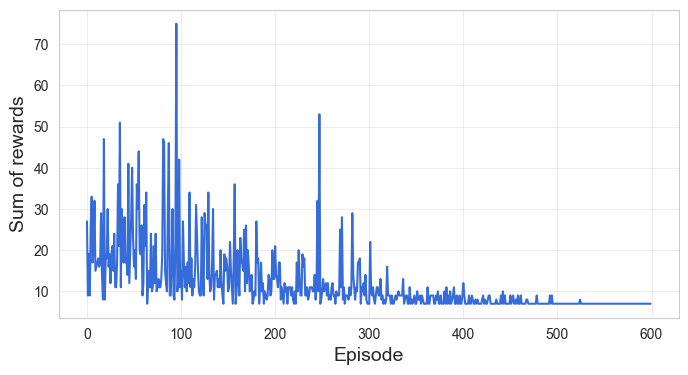

In [47]:
plt.figure(figsize=(8, 4))
plt.plot(rewards)
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.show()

In [52]:
state, info = env.reset(seed=42)

frames = []

for step in range(200):
    action = epsilon_greedy_policy(state)
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    frames.append(env.render())

    if done:
        break

plot_animation(frames)